## Análise de Crédito ML

* credit.policy: 1 se o cliente atender aos critérios de subscrição de crédito da LendingClub.com e 0 caso contrário.
* purpose: O objetivo do empréstimo (possíveis valores "credit_card", "debt_consolidation", "educacional", "major_purchase", "small_business" e "all_other").
* int.rate: a taxa de juros do empréstimo (uma taxa de 11% seria armazenada como 0.11). Os mutuários julgados por LendingClub.com para serem mais arriscados recebem taxas de juros mais elevadas.
* installment: as parcelas mensais devidas pelo mutuário se o empréstimo for financiado.
* log.annual.inc: O log natural da renda anual auto-relatada do mutuário.
* dti: Ratio dívida / rendimento do tomador do empréstimo (montante da dívida dividido pela receita anual).
* fico: a pontuação de crédito FICO do mutuário.
* days.with.cr.line: O número de dias em que o mutuário teve uma linha de crédito.
* revol.bal: Saldo rotativo do mutuário (montante não pago no final do ciclo de cobrança do cartão de crédito).
* revol.util: taxa de utilização da linha rotativa do mutuário (o valor da linha de crédito usada em relação ao crédito total disponível).
* inq.last.6mths: número de consultas do mutuário por credores nos últimos 6 meses.
* delinq.2yrs: o número de vezes que o mutuário havia passado mais de 30 dias em um pagamento nos últimos 2 anos.
* pub.rec: O número de registros públicos depreciativos do mutuário (arquivamentos de falências, ônus fiscais ou julgamentos).
* not.fully.paid: inadimplência, pagou ou não o empréstimo na íntegra

## ETL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/dados.csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB


In [5]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


## Credit Policy x FICO

Text(0, 0.5, 'Quantidade')

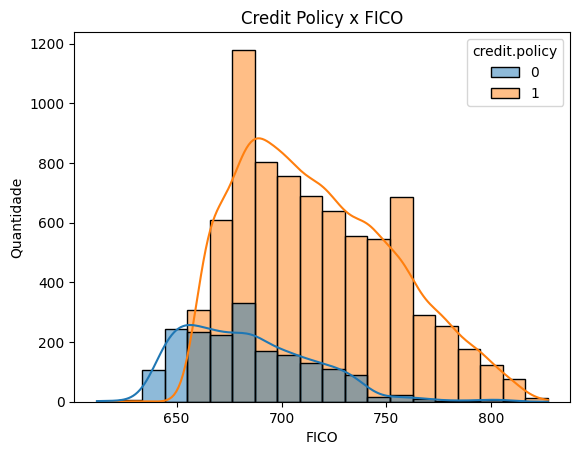

In [6]:
sns.histplot(data=df, x="fico", hue="credit.policy", bins=20, kde=True)
plt.title("Credit Policy x FICO")
plt.xlabel("FICO")
plt.ylabel("Quantidade")

## Not Fully Paid x FICO

Text(0, 0.5, 'Quantidade')

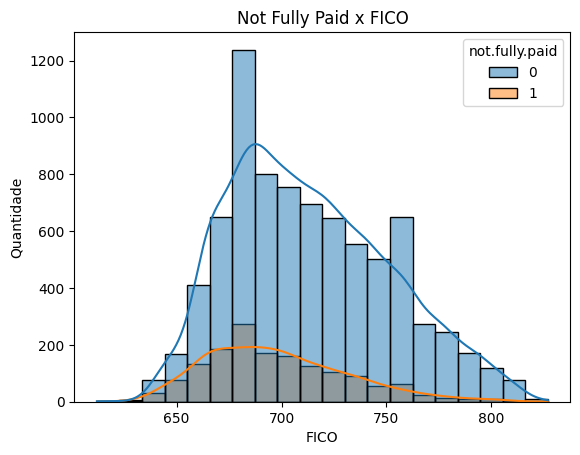

In [7]:
sns.histplot(data=df, x="fico", hue="not.fully.paid", bins=20, kde=True)
plt.title("Not Fully Paid x FICO")
plt.xlabel("FICO")
plt.ylabel("Quantidade")

## Contagem de Empréstimos por Finalidade

Text(0, 0.5, 'Quantidade')

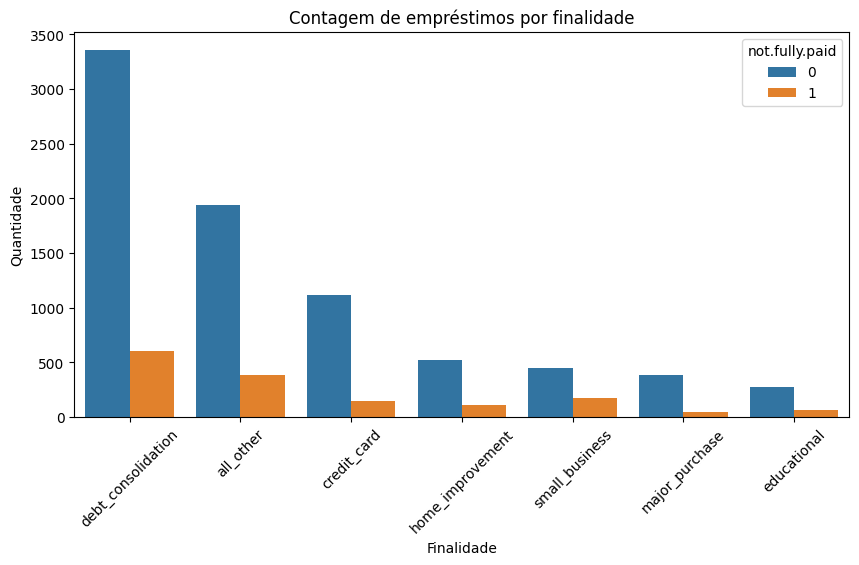

In [8]:
order = df['purpose'].value_counts().index

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="purpose", hue="not.fully.paid", order=order)

plt.xticks(rotation=45)
plt.title("Contagem de empréstimos por finalidade")
plt.xlabel("Finalidade")
plt.ylabel("Quantidade")

## Int. Rate x FICO

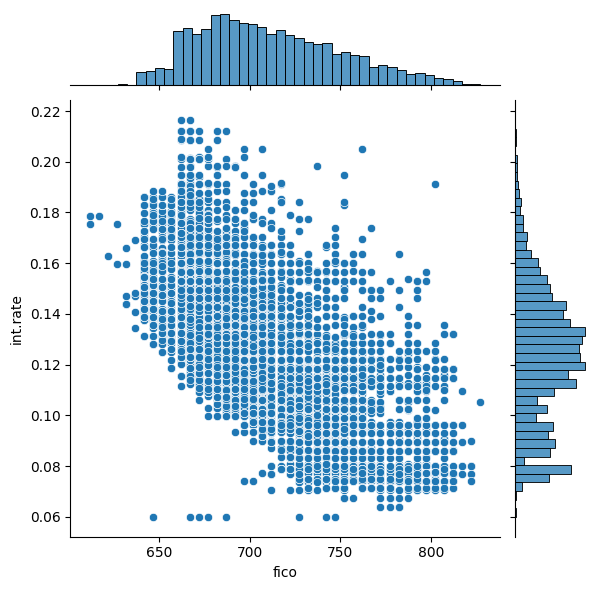

In [9]:
sns.jointplot(data=df, x="fico", y="int.rate")

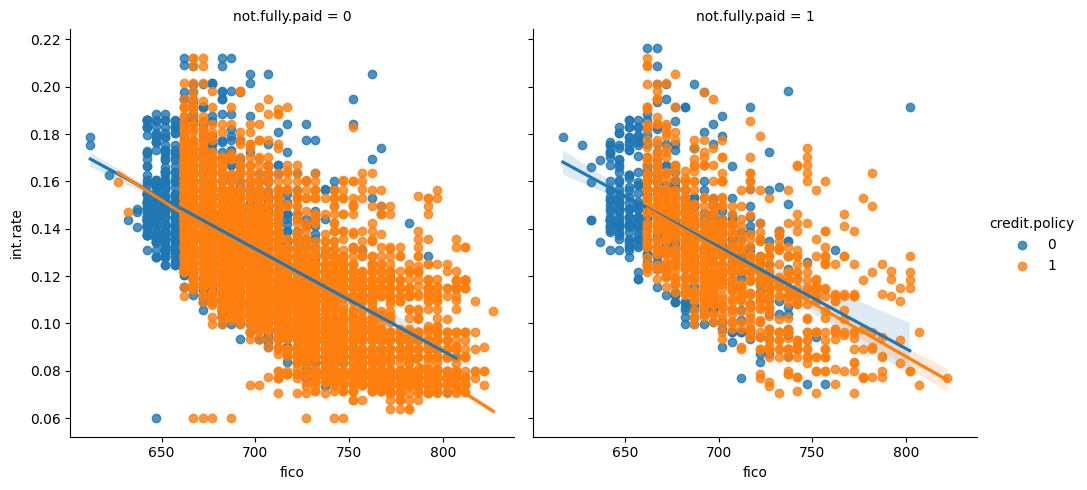

In [10]:
sns.lmplot(
    data=df,
    x="fico",
    y="int.rate",
    hue="credit.policy",
    col="not.fully.paid"
)

## Machine Learning

In [11]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [12]:
purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True)

In [13]:
purpose_dummies

,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,False,True,False,False,False,False
1,True,False,False,False,False,False
2,False,True,False,False,False,False
3,False,True,False,False,False,False
4,True,False,False,False,False,False
...,...,...,...,...,...,...
9573,False,False,False,False,False,False
9574,False,False,False,False,False,False
9575,False,True,False,False,False,False
9576,False,False,False,True,False,False


In [14]:
df_final = pd.concat([df, purpose_dummies], axis=1)
df_final

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1,False,False,False,False,False,False
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1,False,False,False,False,False,False
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1,False,True,False,False,False,False
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1,False,False,False,True,False,False


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
x = df_final.drop(['not.fully.paid', 'purpose'], axis=1)
y = df_final['not.fully.paid'] 

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## Decision Tree Classifier

In [17]:
from sklearn.tree import plot_tree, DecisionTreeClassifier

In [18]:
dtc_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtc_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [19]:
y_pred = dtc_model.predict(x_test)

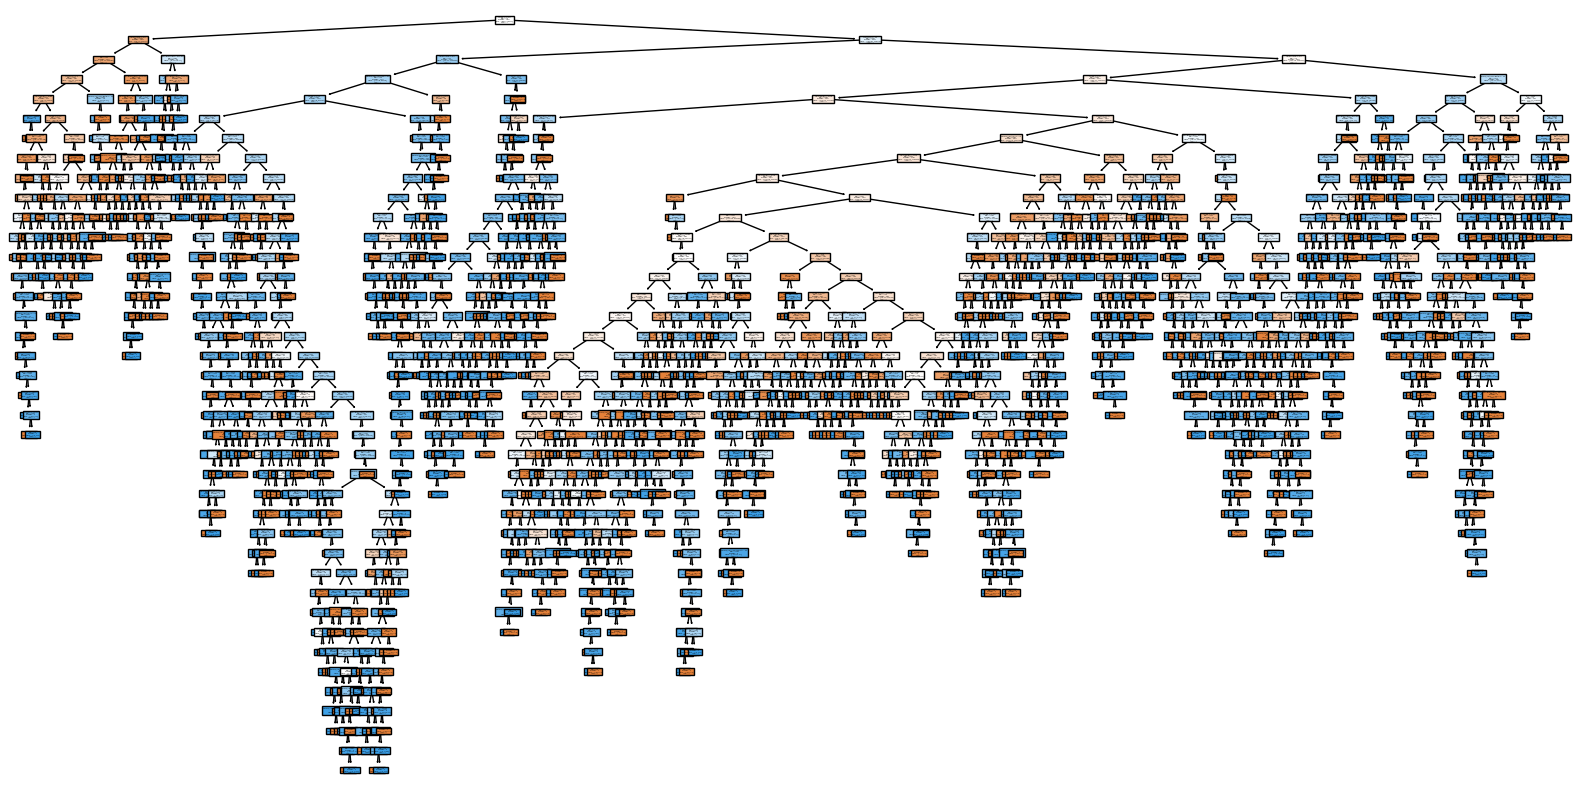

In [20]:
plt.figure(figsize=(20,10))

plot_tree(
    dtc_model,
    feature_names=x.columns,
    class_names=['0', '1'],
    filled=True
)

plt.show()

In [21]:
resultado = df_final.loc[x_test.index].copy()

resultado['real'] = y_test
resultado['predict'] = y_pred

resultado.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,...,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,real,predict
8558,0,debt_consolidation,0.1545,453.52,10.596635,14.52,657,3810.000000,8545,82.2,...,0,0,False,True,False,False,False,False,0,0
4629,1,debt_consolidation,0.1183,533.46,11.156251,10.89,732,3600.000000,15942,40.9,...,0,0,False,True,False,False,False,False,0,1
1383,1,credit_card,0.1146,197.75,10.348173,13.73,692,2069.958333,14154,85.8,...,0,1,True,False,False,False,False,False,1,0
8142,0,all_other,0.1646,106.16,11.002100,28.16,672,6480.041667,7846,25.8,...,0,0,False,False,False,False,False,False,0,1
1768,1,all_other,0.1221,159.92,11.127322,3.99,702,5040.000000,468,7.2,...,0,0,False,False,False,False,False,False,0,0


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1611
           1       0.23      0.26      0.24       305

    accuracy                           0.74      1916
   macro avg       0.54      0.55      0.54      1916
weighted avg       0.76      0.74      0.75      1916



In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

# [[TN FP]
#  [FN TP]]

[[1344  267]
 [ 226   79]]


TN (True Negative)
Previu 0 e era 0

FP (False Positive)
Previu 1, mas era 0

FN (False Negative)
Previu 0, mas era 1

TP (True Positive)
Previu 1 e era 1

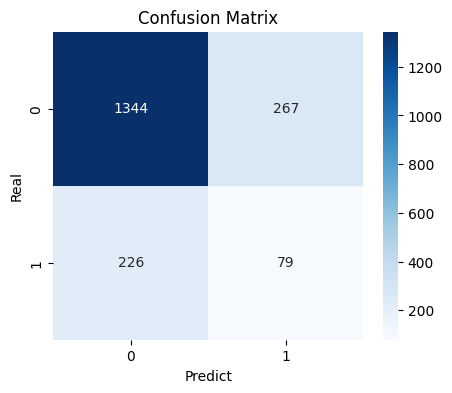

In [24]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    data=cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # xticklabels=['Pago', 'Não Pago'],
    # yticklabels=['Pago', 'Não Pago']
)
plt.xlabel('Predict')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

## Random Forest Classifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rfc = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=300,
    max_depth=10
)

In [27]:
rfc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [28]:
y_pred_rfc = rfc.predict(x_test)

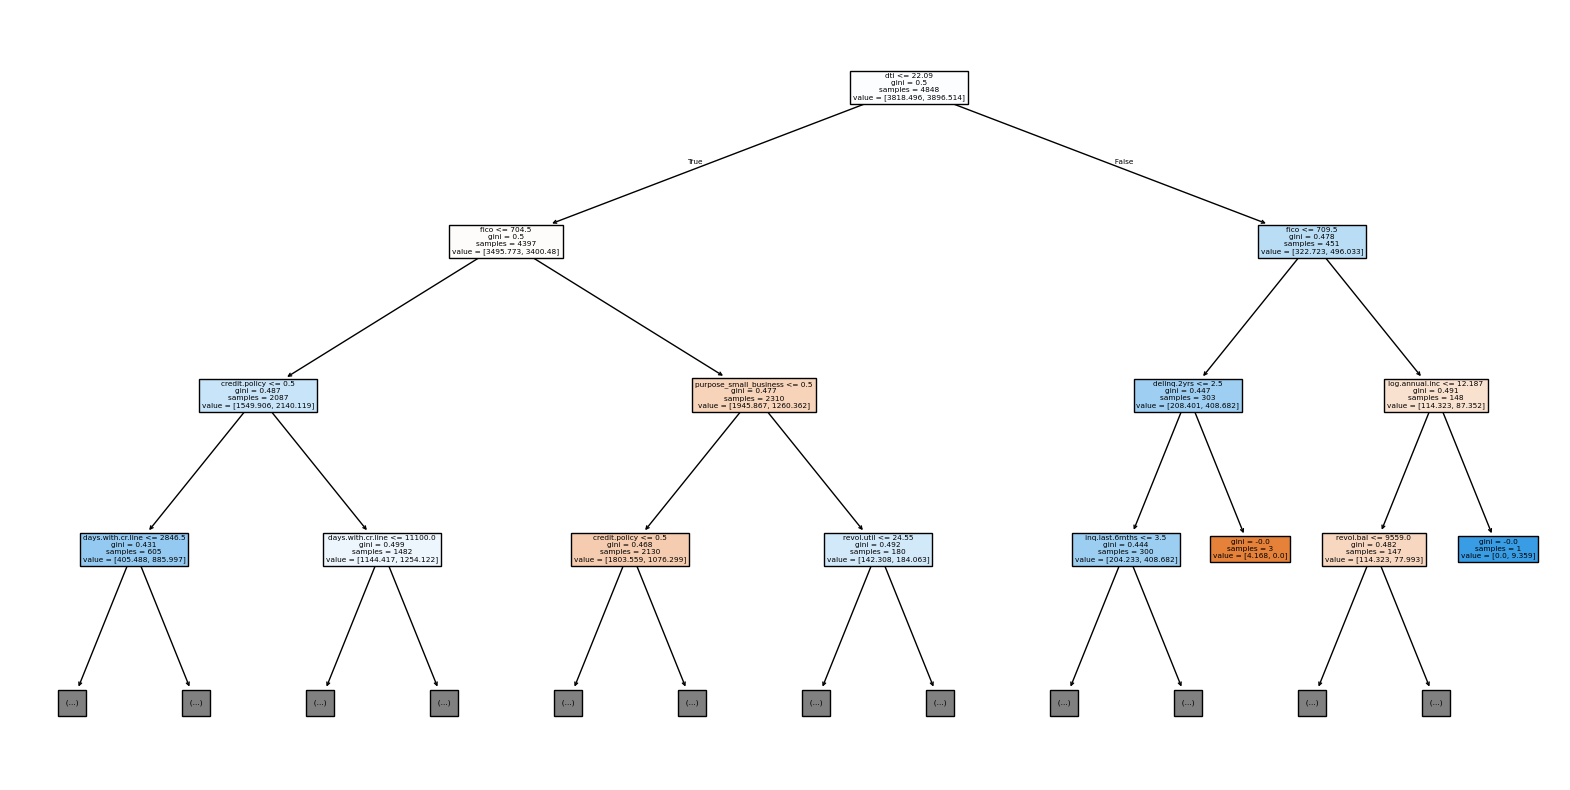

In [29]:
tree = rfc.estimators_[0]

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=x.columns,
    filled=True,
    max_depth=3
)
plt.show()

In [30]:
resultado = df_final.loc[x_test.index].copy()

resultado['real'] = y_test
resultado['predict'] = y_pred_rfc

resultado.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,...,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,real,predict
8558,0,debt_consolidation,0.1545,453.52,10.596635,14.52,657,3810.000000,8545,82.2,...,0,0,False,True,False,False,False,False,0,1
4629,1,debt_consolidation,0.1183,533.46,11.156251,10.89,732,3600.000000,15942,40.9,...,0,0,False,True,False,False,False,False,0,0
1383,1,credit_card,0.1146,197.75,10.348173,13.73,692,2069.958333,14154,85.8,...,0,1,True,False,False,False,False,False,1,0
8142,0,all_other,0.1646,106.16,11.002100,28.16,672,6480.041667,7846,25.8,...,0,0,False,False,False,False,False,False,0,0
1768,1,all_other,0.1221,159.92,11.127322,3.99,702,5040.000000,468,7.2,...,0,0,False,False,False,False,False,False,0,0


In [31]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1611
           1       0.26      0.22      0.24       305

    accuracy                           0.78      1916
   macro avg       0.56      0.55      0.55      1916
weighted avg       0.76      0.78      0.77      1916



In [32]:
cm = confusion_matrix(y_test, y_pred_rfc)

print(cm)

# [[TN FP]
#  [FN TP]]

[[1417  194]
 [ 237   68]]


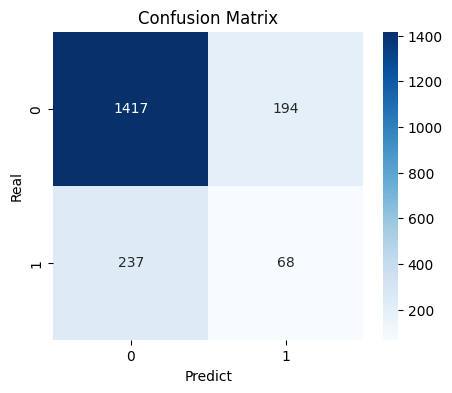

In [33]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    data=cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # xticklabels=['Pago', 'Não Pago'],
    # yticklabels=['Pago', 'Não Pago']
)
plt.xlabel('Predict')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

## XGBoost

In [34]:
from xgboost import plot_importance, to_graphviz, XGBClassifier

In [35]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

scale_pos_weight

np.float64(5.239413680781759)

In [36]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [37]:
y_proba = xgb_model.predict_proba(x_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_proba > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1611
           1       0.26      0.31      0.28       305

    accuracy                           0.75      1916
   macro avg       0.56      0.57      0.56      1916
weighted avg       0.77      0.75      0.76      1916


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      1611
           1       0.23      0.47      0.30       305

    accuracy                           0.66      1916
   macro avg       0.55      0.58      0.54      1916
weighted avg       0.77      0.66      0.70      1916


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.51      0.65      1611
           1       0.21      0.67      0.31       305

    accuracy                           0.54      1916
   macro avg       0.55      0.59      0.48      1916
weighted avg       0.78   

In [38]:
y_pred_xgb = (y_proba > 0.4).astype(int)

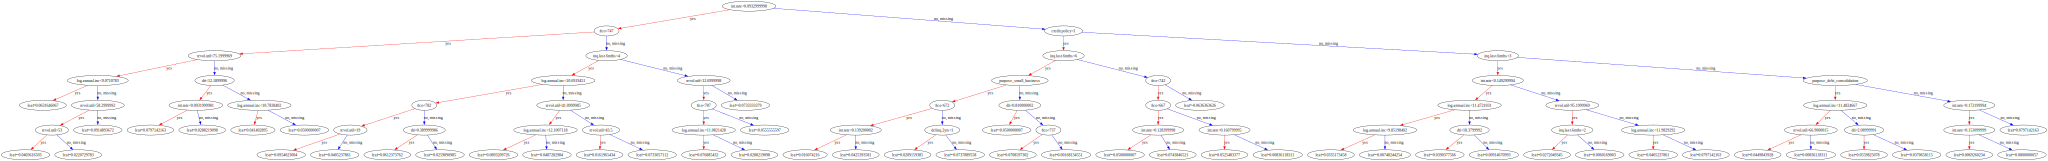

In [39]:
tree = to_graphviz(xgb_model, tree_idx=0)
tree

In [40]:
resultado = df.loc[x_test.index].copy()

resultado['real'] = y_test
resultado['predict'] = y_pred_xgb

resultado.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,real,predict
8558,0,debt_consolidation,0.1545,453.52,10.596635,14.52,657,3810.000000,8545,82.2,3,0,0,0,0,1
4629,1,debt_consolidation,0.1183,533.46,11.156251,10.89,732,3600.000000,15942,40.9,3,0,0,0,0,0
1383,1,credit_card,0.1146,197.75,10.348173,13.73,692,2069.958333,14154,85.8,0,0,0,1,1,0
8142,0,all_other,0.1646,106.16,11.002100,28.16,672,6480.041667,7846,25.8,4,1,0,0,0,1
1768,1,all_other,0.1221,159.92,11.127322,3.99,702,5040.000000,468,7.2,1,1,0,0,0,0


In [41]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      1611
           1       0.23      0.47      0.30       305

    accuracy                           0.66      1916
   macro avg       0.55      0.58      0.54      1916
weighted avg       0.77      0.66      0.70      1916



In [42]:
cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

# [[TN FP]
#  [FN TP]]

[[1115  496]
 [ 161  144]]


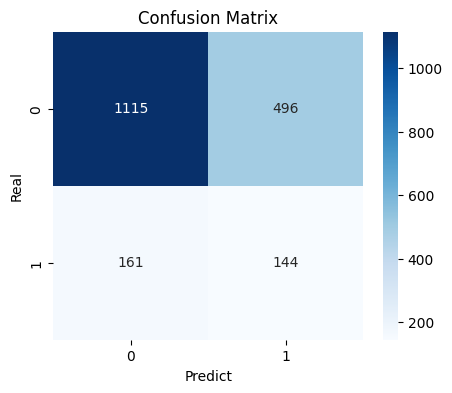

In [43]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    data=cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # xticklabels=['Pago', 'Não Pago'],
    # yticklabels=['Pago', 'Não Pago']
)
plt.xlabel('Predict')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()

E:\Programacao\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


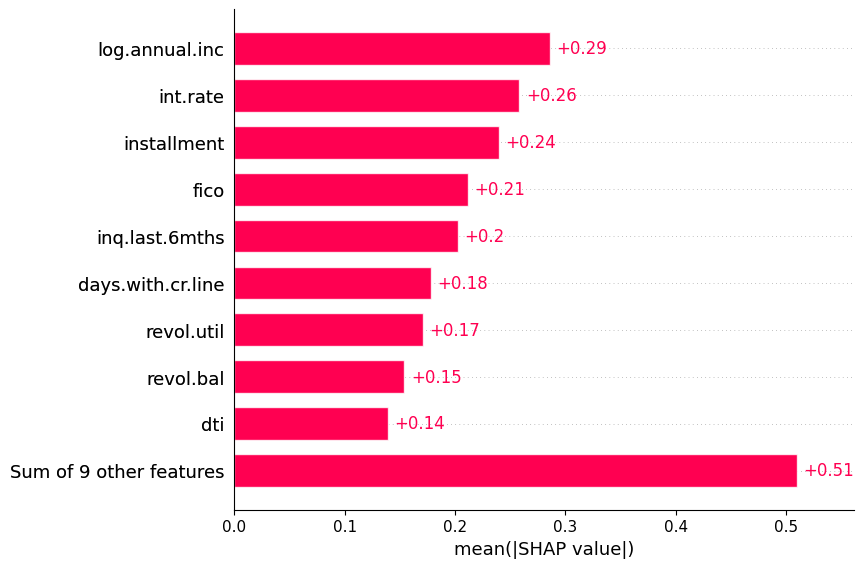

In [44]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(x_test)

shap.plots.bar(shap_values)